Dataset shape: (32000, 10)

Column data types:
platform         object
brand            object
product_name     object
category         object
price             int64
rating          float64
ram              object
storage          object
battery          object
url              object
dtype: object

Missing values per column:
platform        0
brand           0
product_name    0
category        0
price           0
rating          0
ram             0
storage         0
battery         0
url             0
dtype: int64

Number of duplicate rows: 0

Summary statistics:
               count          mean           std     min       25%      50%  \
price        32000.0  41786.395219  19291.785462  8156.0  25133.75  39922.0   
rating       32000.0      4.215628      0.404792     3.5      3.90      4.2   
ram_gb       32000.0      9.162375      4.296360     4.0      6.00      8.0   
storage_gb   32000.0    390.801750    340.654348    64.0    128.00    256.0   
battery_mah  32000.0   5005.62500

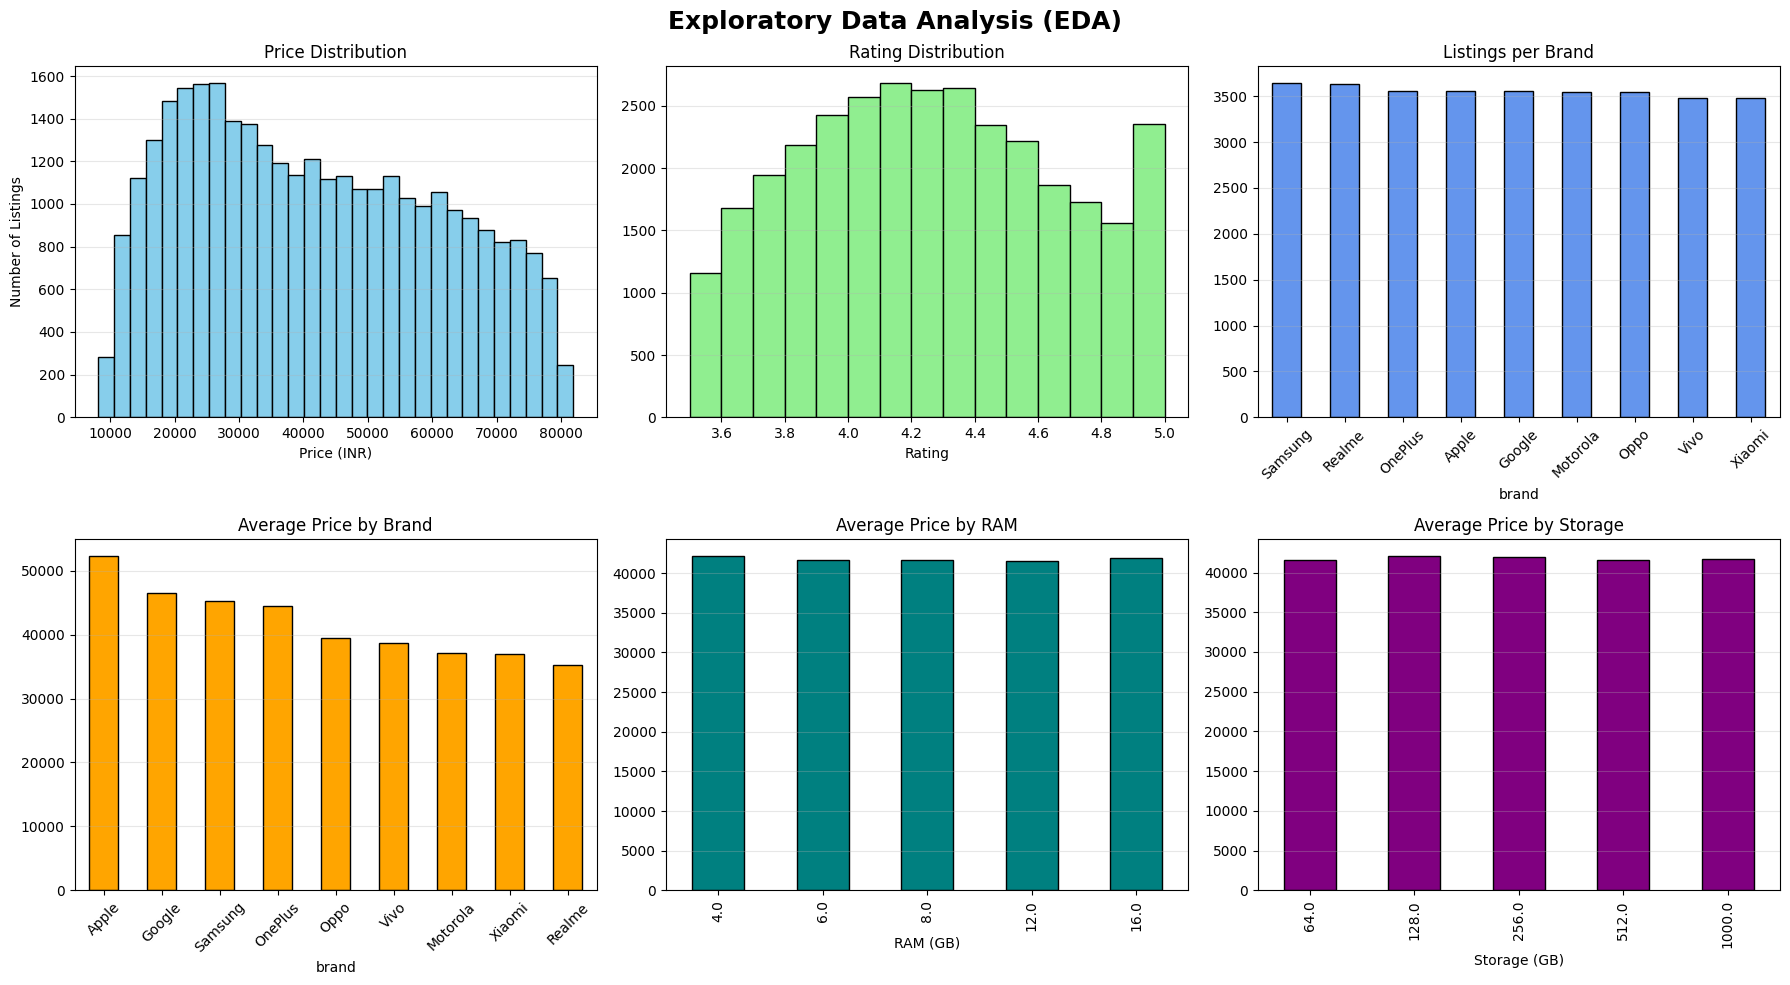

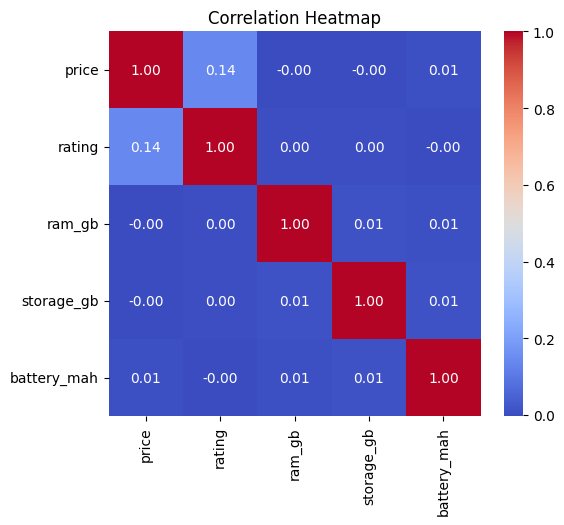

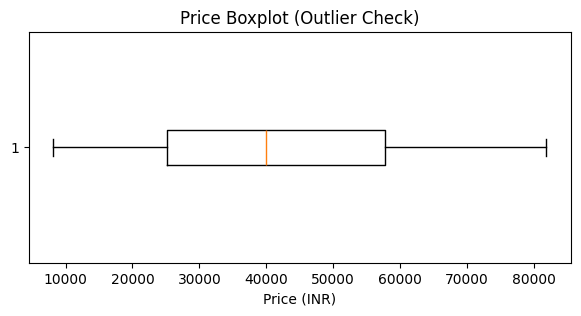

Spec combinations that appear more than once: 4770
Rows affected: 10259 out of 32000
Average price gap for repeated specs: Rs 21330


In [1]:
# =====================================================================
# SECTION 1: EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================================
# Goal: load the raw dataset and understand its structure, quality,
# and key patterns before any cleaning or modeling is done.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------
# 1.1 Load the dataset
# ---------------------------------------------------------------
# NOTE: update this path to wherever "Dataset 2.csv" is stored on your machine
DATA_PATH = r"D:\[18] AI-ML All\inttrvu AI\Group Project - 1\ML_Regression_Project\data\Dataset 2.csv"
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

# ---------------------------------------------------------------
# 1.2 Structure, data types, missing values, duplicates
# ---------------------------------------------------------------
print("\nColumn data types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())

# ---------------------------------------------------------------
# 1.3 Parse numeric values out of text columns (for plotting only;
#     these columns are re-cleaned properly in the Preprocessing section)
# ---------------------------------------------------------------
df["ram_gb"]      = df["ram"].str.replace("GB", "", regex=False).astype(float)
df["storage_gb"]  = (
    df["storage"].str.replace("TB", "000", regex=False)
    .str.replace("GB", "", regex=False).astype(float)
)
df["battery_mah"] = df["battery"].str.replace("mAh", "", regex=False).astype(float)

# ---------------------------------------------------------------
# 1.4 Summary statistics
# ---------------------------------------------------------------
print("\nSummary statistics:")
print(df[["price", "rating", "ram_gb", "storage_gb", "battery_mah"]].describe().transpose())

# ---------------------------------------------------------------
# 1.5 Visual EDA: distributions, brand comparisons, correlations
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Exploratory Data Analysis (EDA)", fontsize=18, fontweight="bold")

# Price distribution
axes[0, 0].hist(df["price"], bins=30, edgecolor="black", color="skyblue")
axes[0, 0].set_title("Price Distribution")
axes[0, 0].set_xlabel("Price (INR)")
axes[0, 0].set_ylabel("Number of Listings")
axes[0, 0].grid(axis="y", alpha=0.3)

# Rating distribution
axes[0, 1].hist(df["rating"], bins=15, edgecolor="black", color="lightgreen")
axes[0, 1].set_title("Rating Distribution")
axes[0, 1].set_xlabel("Rating")
axes[0, 1].grid(axis="y", alpha=0.3)

# Listings per brand
brand_counts = df["brand"].value_counts()
brand_counts.plot(kind="bar", ax=axes[0, 2], edgecolor="black", color="cornflowerblue")
axes[0, 2].set_title("Listings per Brand")
axes[0, 2].tick_params(axis="x", rotation=45)
axes[0, 2].grid(axis="y", alpha=0.3)

# Average price by brand
avg_price_by_brand = df.groupby("brand")["price"].mean().sort_values(ascending=False)
avg_price_by_brand.plot(kind="bar", ax=axes[1, 0], edgecolor="black", color="orange")
axes[1, 0].set_title("Average Price by Brand")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(axis="y", alpha=0.3)

# Average price by RAM
df.groupby("ram_gb")["price"].mean().plot(kind="bar", ax=axes[1, 1], edgecolor="black", color="teal")
axes[1, 1].set_title("Average Price by RAM")
axes[1, 1].set_xlabel("RAM (GB)")
axes[1, 1].grid(axis="y", alpha=0.3)

# Average price by storage
df.groupby("storage_gb")["price"].mean().plot(kind="bar", ax=axes[1, 2], edgecolor="black", color="purple")
axes[1, 2].set_title("Average Price by Storage")
axes[1, 2].set_xlabel("Storage (GB)")
axes[1, 2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Correlation heatmap
numeric_cols = ["price", "rating", "ram_gb", "storage_gb", "battery_mah"]
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Outlier check on price
plt.figure(figsize=(7, 3))
plt.boxplot(df["price"], vert=False)
plt.title("Price Boxplot (Outlier Check)")
plt.xlabel("Price (INR)")
plt.show()

# ---------------------------------------------------------------
# 1.6 Data quality check: same specs, very different price
# ---------------------------------------------------------------
# If two listings share identical specs but have very different prices,
# that's a red flag for modeling: the model sees the same input but is
# asked to predict two different targets.
spec_cols = ["brand", "ram", "storage", "battery", "rating", "platform"]
price_check = df.groupby(spec_cols)["price"].agg(["min", "max", "count"])
price_check["price_gap"] = price_check["max"] - price_check["min"]
repeated_specs = price_check[price_check["count"] > 1]

print("Spec combinations that appear more than once:", len(repeated_specs))
print("Rows affected:", repeated_specs["count"].sum(), "out of", len(df))
if len(repeated_specs) > 0:
    print("Average price gap for repeated specs: Rs", round(repeated_specs["price_gap"].mean()))


SUBSET_MODE = 'synthetic_only' -> 12,000 rows kept
Shape after cleaning: (12000, 10)
Final feature set: ['platform', 'brand', 'price', 'rating', 'ram', 'storage', 'battery', 'ram_gb', 'storage_gb', 'battery_mah', 'total_memory', 'ram_storage', 'battery_per_ram', 'storage_per_ram', 'rating_ram', 'rating_storage', 'rating_battery']


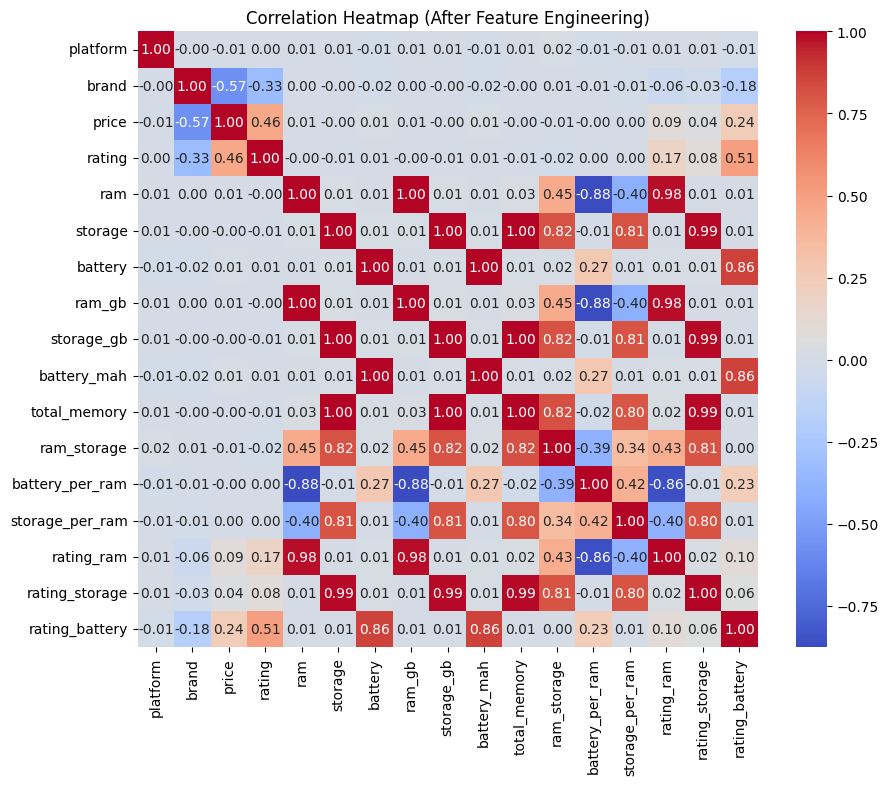

Training shape: (9600, 16)
Testing shape : (2400, 16)


In [2]:
# =====================================================================
# SECTION 2: DATA PREPROCESSING
# =====================================================================
# Goal: clean the raw dataset, engineer numeric features, encode
# categorical variables, and prepare train/test splits for modeling.
# (Uses the `df` loaded in Section 1 — run cells in order.)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------------
# 2.1 (Optional) keep only original / synthetic / all rows
# ---------------------------------------------------------------
# product_name values that look like "brand-123" are synthetic rows
# added to the dataset; SUBSET_MODE controls which rows are kept.
# SUBSET_MODE = "all"
# SUBSET_MODE = "original_only"
SUBSET_MODE = "synthetic_only"

df["is_synthetic_like"] = df["product_name"].str.contains(
    r"\b[a-z]+-\d+(?:-[a-z]+)?\b", regex=True
)

if SUBSET_MODE == "original_only":
    df = df[~df["is_synthetic_like"]].copy()
elif SUBSET_MODE == "synthetic_only":
    df = df[df["is_synthetic_like"]].copy()
elif SUBSET_MODE != "all":
    raise ValueError(f"Unknown SUBSET_MODE: {SUBSET_MODE!r}")

df = df.drop(columns=["is_synthetic_like"])
print(f"SUBSET_MODE = {SUBSET_MODE!r} -> {len(df):,} rows kept")

# ---------------------------------------------------------------
# 2.2 Clean numeric columns and drop non-predictive columns
# ---------------------------------------------------------------
# ram / storage / battery have "GB"/"TB"/"mAh" suffixes -> strip and
# convert to numeric. price / rating are converted to numeric as a
# safety net. "category" is constant ("Smartphone" for every row) so
# it carries no information; "product_name" and "url" are just
# identifiers, not predictive features.
processed_df = df.copy()

processed_df["price"]  = pd.to_numeric(processed_df["price"], errors="coerce")
processed_df["rating"] = pd.to_numeric(processed_df["rating"], errors="coerce")

processed_df["ram"] = processed_df["ram"].astype(str).str.extract(r"(\d+)").astype(float)
processed_df["storage"] = (
    processed_df["storage"].astype(str).str.replace("TB", "000", regex=False)
    .str.extract(r"(\d+)").astype(float)
)
processed_df["battery"] = processed_df["battery"].astype(str).str.extract(r"(\d+)").astype(float)

# Drop rows with missing values in key columns (none expected, kept for robustness)
processed_df = processed_df.dropna(subset=["price", "rating", "ram", "storage", "battery"])

# Drop columns with no predictive value
processed_df = processed_df.drop(columns=["category", "url", "product_name"], errors="ignore")

print("Shape after cleaning:", processed_df.shape)
processed_df.head()

# ---------------------------------------------------------------
# 2.3 Encode categorical columns (brand, platform)
# ---------------------------------------------------------------
# Label encoding was chosen after comparing Label / Ordinal / Binary /
# One-Hot encodings across all three models (see report for the
# full comparison table).
# for col in ["brand", "platform"]:
#     le = LabelEncoder()
#     processed_df[col] = le.fit_transform(processed_df[col])
    
    
encoders = {}
for col in ["brand", "platform"]:
    le = LabelEncoder()
    processed_df[col] = le.fit_transform(processed_df[col])
    encoders[col] = le   # keep each column's encoder so we can decode later

# ---------------------------------------------------------------
# 2.4 Feature engineering
# ---------------------------------------------------------------
processed_df["total_memory"]    = processed_df["ram"] + processed_df["storage"]
processed_df["ram_storage"]     = processed_df["ram"] * processed_df["storage"]
processed_df["battery_per_ram"] = processed_df["battery"] / processed_df["ram"]
processed_df["storage_per_ram"] = processed_df["storage"] / processed_df["ram"]
processed_df["rating_ram"]      = processed_df["rating"] * processed_df["ram"]
processed_df["rating_storage"]  = processed_df["rating"] * processed_df["storage"]
processed_df["rating_battery"]  = processed_df["rating"] * processed_df["battery"]

print("Final feature set:", processed_df.columns.tolist())

# Correlation heatmap after feature engineering
plt.figure(figsize=(10, 8))
sns.heatmap(processed_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (After Feature Engineering)")
plt.show()

# ---------------------------------------------------------------
# 2.5 Train/test split + scaling
# ---------------------------------------------------------------
X = processed_df.drop(columns=["price"])
y = processed_df["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling is only needed for Linear Regression; tree-based models
# (Random Forest, XGBoost) work directly on unscaled features.
scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train)
X_test_lr  = scaler.transform(X_test)

X_train_tree = X_train.copy()
X_test_tree  = X_test.copy()

print("Training shape:", X_train.shape)
print("Testing shape :", X_test.shape)



Linear Regression
MAE : 10097.452113510668
RMSE: 12472.829871244943
R2  : 0.4124635612367401


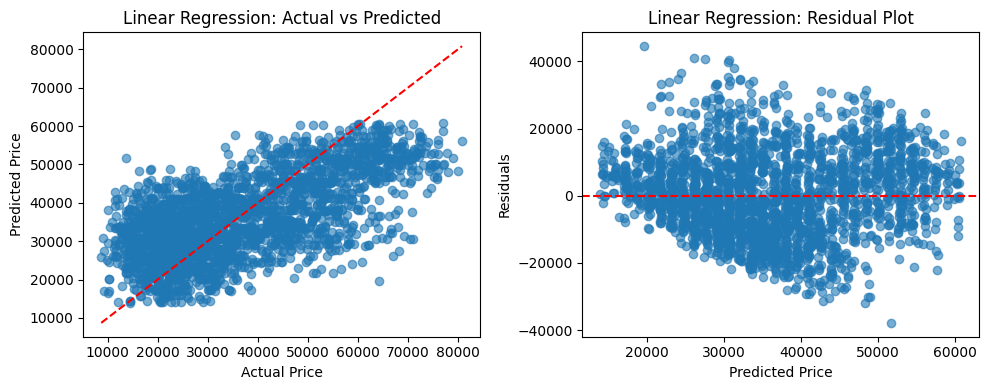


Random Forest
MAE : 6351.767194440064
RMSE: 8174.5114241762385
R2  : 0.7476354089787355


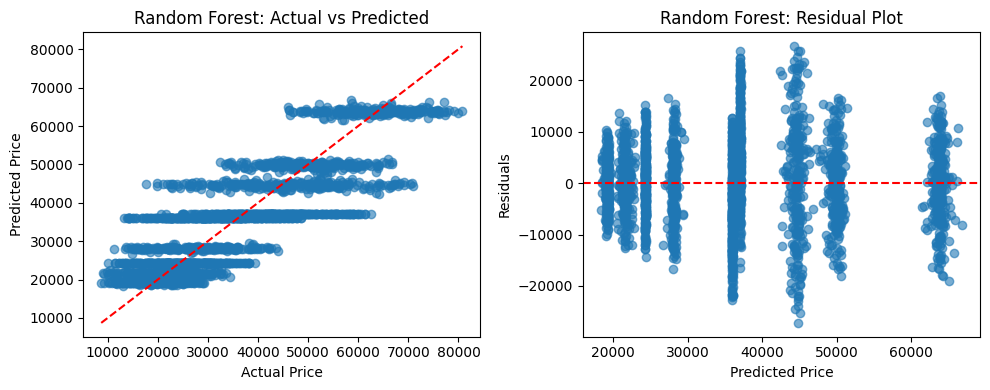


XGBoost
MAE : 6107.2724609375
RMSE: 7792.19044941793
R2  : 0.7706895470619202


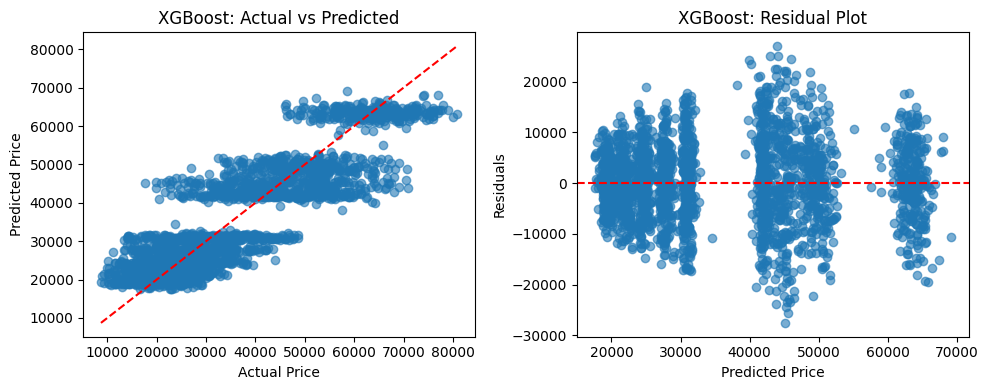


Model Comparison:
               Model           MAE          RMSE  R2 Score
0            XGBoost   6107.272461   7792.190449  0.770690
1      Random Forest   6351.767194   8174.511424  0.747635
2  Linear Regression  10097.452114  12472.829871  0.412464


In [3]:
# =====================================================================
# SECTION 3: ML ALGORITHM IMPLEMENTATION
# =====================================================================
# Goal: train Linear Regression, Random Forest, and XGBoost regressors
# to predict smartphone price, evaluate each, and compare results.
# (Uses X_train / X_test / y_train / y_test from Section 2.)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_model(name, y_true, y_pred):
    """Print MAE / RMSE / R2 and plot Actual-vs-Predicted + Residuals."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Actual vs Predicted
    axes[0].scatter(y_true, y_pred, alpha=0.6)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], "r--")
    axes[0].set_xlabel("Actual Price")
    axes[0].set_ylabel("Predicted Price")
    axes[0].set_title(f"{name}: Actual vs Predicted")

    # Residual plot
    residuals = y_true - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.6)
    axes[1].axhline(y=0, color="red", linestyle="--")
    axes[1].set_xlabel("Predicted Price")
    axes[1].set_ylabel("Residuals")
    axes[1].set_title(f"{name}: Residual Plot")

    plt.tight_layout()
    plt.show()

    return mae, rmse, r2


# ---------------------------------------------------------------
# 3.1 Linear Regression (uses scaled features)
# ---------------------------------------------------------------
lin_model = LinearRegression()
lin_model.fit(X_train_lr, y_train)
y_pred_lr = lin_model.predict(X_test_lr)
mae_lr, rmse_lr, r2_lr = evaluate_model("Linear Regression", y_test, y_pred_lr)

# ---------------------------------------------------------------
# 3.2 Random Forest Regressor (uses raw features)
# ---------------------------------------------------------------
rf_model = RandomForestRegressor(
    random_state=42, n_estimators=300, max_depth=5, min_samples_leaf=1, min_samples_split=2
)
rf_model.fit(X_train_tree, y_train)
y_pred_rf = rf_model.predict(X_test_tree)
mae_rf, rmse_rf, r2_rf = evaluate_model("Random Forest", y_test, y_pred_rf)

# ---------------------------------------------------------------
# 3.3 XGBoost Regressor (uses raw features)
# ---------------------------------------------------------------
xgb_model = XGBRegressor(
    random_state=42,
    n_estimators=500,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
)
xgb_model.fit(X_train_tree, y_train)
y_pred_xgb = xgb_model.predict(X_test_tree)
mae_xgb, rmse_xgb, r2_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb)

# ---------------------------------------------------------------
# 3.4 Model comparison table
# ---------------------------------------------------------------
comparison = pd.DataFrame({
    "Model":    ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE":      [mae_lr, mae_rf, mae_xgb],
    "RMSE":     [rmse_lr, rmse_rf, rmse_xgb],
    "R2 Score": [r2_lr, r2_rf, r2_xgb],
}).sort_values("R2 Score", ascending=False).reset_index(drop=True)

print("\nModel Comparison:")
print(comparison)


               Model  Price per +1GB RAM (Rs)  Price per +1GB Storage (Rs)
0  Linear Regression                 6.110950                    -1.374602
1      Random Forest                -1.898631                    -0.717173
2            XGBoost                13.461426                     0.000000


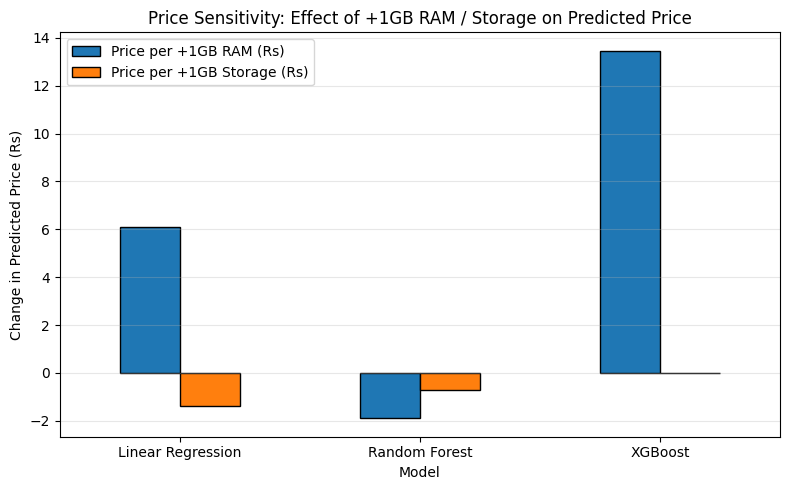

In [4]:
# =====================================================================
# PRICE SENSITIVITY ANALYSIS
# =====================================================================
# How much does the model think one extra GB of RAM / storage is worth?
# Approach: bump the feature up by 1 for every row in the test set,
# re-predict, and average the change in predicted price. Engineered
# features (ram_storage, total_memory, etc.) are recomputed so the
# comparison stays consistent with how the model was trained.

def recompute_features(X):
    """Refresh engineered columns after changing ram/storage/battery/rating."""
    X = X.copy()
    X["total_memory"]    = X["ram"] + X["storage"]
    X["ram_storage"]     = X["ram"] * X["storage"]
    X["battery_per_ram"] = X["battery"] / X["ram"]
    X["storage_per_ram"] = X["storage"] / X["ram"]
    X["rating_ram"]      = X["rating"] * X["ram"]
    X["rating_storage"]  = X["rating"] * X["storage"]
    X["rating_battery"]  = X["rating"] * X["battery"]
    return X

def marginal_effect(model, X, feature, step=1, scaler=None):
    """Average predicted-price change from a +step bump in `feature`."""
    X_base = recompute_features(X)
    X_high = X.copy()
    X_high[feature] = X_high[feature] + step
    X_high = recompute_features(X_high)

    if scaler is not None:          # Linear Regression needs scaled input
        pred_base = model.predict(scaler.transform(X_base))
        pred_high = model.predict(scaler.transform(X_high))
    else:                           # tree models use raw features
        pred_base = model.predict(X_base)
        pred_high = model.predict(X_high)

    return (pred_high - pred_base).mean()

sensitivity = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "Price per +1GB RAM (Rs)": [
        marginal_effect(lin_model, X_test, "ram", scaler=scaler),
        marginal_effect(rf_model, X_test_tree, "ram"),
        marginal_effect(xgb_model, X_test_tree, "ram"),
    ],
    "Price per +1GB Storage (Rs)": [
        marginal_effect(lin_model, X_test, "storage", scaler=scaler),
        marginal_effect(rf_model, X_test_tree, "storage"),
        marginal_effect(xgb_model, X_test_tree, "storage"),
    ],
})

print(sensitivity)

sensitivity.set_index("Model").plot(kind="bar", figsize=(8, 5), edgecolor="black")
plt.title("Price Sensitivity: Effect of +1GB RAM / Storage on Predicted Price")
plt.ylabel("Change in Predicted Price (Rs)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

brand
Apple       63432.207031
Google      49494.957031
Samsung     44939.523438
OnePlus     42208.753906
Oppo        30962.292969
Vivo        27773.884766
Motorola    24632.587891
Xiaomi      21933.605469
Realme      19277.570312
Name: predicted_price, dtype: float32


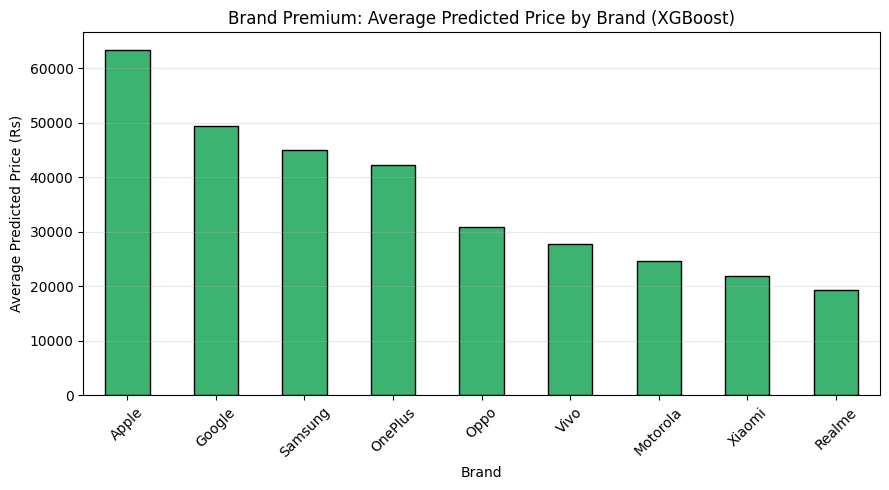

In [5]:
# =====================================================================
# BRAND PREMIUM QUANTIFICATION
# =====================================================================
# Average predicted price by brand, using the best-performing model
# (whichever row is on top of your `comparison` table from Section 3).

best_model_name = comparison.iloc[0]["Model"]
best_model = {"Linear Regression": lin_model, "Random Forest": rf_model, "XGBoost": xgb_model}[best_model_name]

# Predict on the test set with the right feature format for that model
if best_model_name == "Linear Regression":
    y_pred_best = best_model.predict(X_test_lr)
else:
    y_pred_best = best_model.predict(X_test_tree)

# Decode the brand column back from numbers to names
brand_names = encoders["brand"].inverse_transform(X_test["brand"])

brand_premium = (
    pd.DataFrame({"brand": brand_names, "predicted_price": y_pred_best})
    .groupby("brand")["predicted_price"]
    .mean()
    .sort_values(ascending=False)
)

print(brand_premium)

plt.figure(figsize=(9, 5))
brand_premium.plot(kind="bar", edgecolor="black", color="mediumseagreen")
plt.title(f"Brand Premium: Average Predicted Price by Brand ({best_model_name})")
plt.ylabel("Average Predicted Price (Rs)")
plt.xlabel("Brand")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()